In [119]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import fcluster


In [ ]:
file_path = r'C:\Users\User\Documents\PEB\DISCIPLINAS\COB 754 - Analise Inteligente de Dados\dengue_A.csv'
dengue_dataset = pd.read_csv(file_path, sep=';', encoding='utf-8')

# Are there missing values?
any_missing = dengue_dataset.isnull().values.any()
print(f'Are there any missing values? {any_missing}')

# How large is this dataset?
size = dengue_dataset.shape
print(f'This dataset size is: {size}')

# Remove id_pacient
dengue_dataset.drop(columns = ['idpac'], inplace= True)

# What is the variance of each variable?
variance = dengue_dataset.var()
if (variance > 0).all and (variance <= 1).all:
    print('The variance of all variables are between 0 and 1')

# Lowest variances (less information)
sort_variance = variance.sort_values()
lowest_5 = sort_variance.head(5)
print(f'The lowest variables with the lowest variables are: \n {lowest_5}')

Are there any missing values? False
This dataset size is: (622, 29)
The variance of all variables are between 0 and 1
The lowest variables with the lowest variables are: 
 altast       0.012717
nppre        0.020496
 tourniq+    0.026627
coldskin     0.034174
neuro        0.040118
dtype: float64


In [61]:
# Hierarquical Clustering using Hamming distance
dist_matrix_condensed = pdist(dengue_dataset, metric='hamming') # Calculates Hamming distance
dist_matrix_squared = squareform(dist_matrix_condensed) # Converts to a square DataFrame for easier viewing
dist_df = pd.DataFrame(dist_matrix_squared, index = dengue_dataset.index, columns = dengue_dataset.index)
linked_clusters = linkage(dist_matrix_condensed, method = 'average', metric='hamming')


cluster
1    597
3     19
2      6
Name: count, dtype: int64
Centros: [39.838169642857146, 176.5, 243.03977272727272]


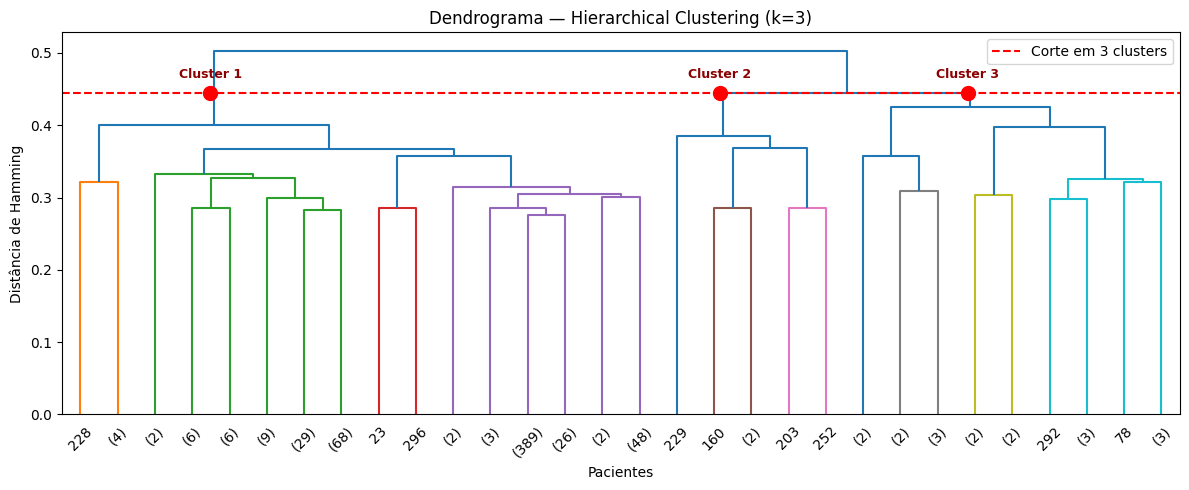

cluster            1         2         3
nau/vom     0.465662  0.833333  0.842105
rash        0.453936  0.666667  0.315789
abpainhist  0.383585  0.500000  0.842105
myal        0.731993  0.333333  0.473684
athral      0.457286  0.000000  0.105263
retpain     0.470687  0.500000  0.368421
 tourniq+   0.025126  0.333333  0.000000
pet         0.298157  0.500000  0.789474
leukop      0.477387  1.000000  0.421053
abpainws    0.376884  0.166667  0.736842
pvomws      0.425461  0.833333  0.736842
cfaws       0.152429  0.500000  0.894737
bleed       0.261307  1.000000  0.578947
letha       0.043551  1.000000  0.631579
liverenws   0.115578  0.500000  0.578947
htopltws    0.167504  0.500000  0.578947
dehydspl    0.237856  0.166667  0.368421
edema.sp    0.067002  0.333333  0.473684
hypo        0.046901  0.833333  0.526316
nppre       0.013400  0.000000  0.263158
coldskin    0.015075  0.166667  0.631579
rwpspl      0.016750  0.333333  0.894737
scf         0.041876  0.000000  0.947368
respdist    0.04

In [ ]:
# Defines 3 clusters for the dendrogram (there are only 3 options: mild, moderate, severe)
labels = fcluster(linked_clusters, t=3, criterion='maxclust')
dengue_dataset['cluster'] = labels

# Verifies how many patients in each cluster
print(dengue_dataset['cluster'].value_counts())

fig, ax = plt.subplots(figsize=(12, 5))

dend = dendrogram(linked_clusters, truncate_mode='lastp', p=30, ax=ax)

cut_height = linked_clusters[-(3-1), 2]
ax.axhline(y=cut_height, color='red', linestyle='--', label='3 clusters cut')

# Gets all x in the dendrogram
all_x = [x for xs in dend['icoord'] for x in xs]

# Cluster 1: x < 40.86
# Cluster 2: 40.86 < x < 210.625  
# Cluster 3: x > 210.625
c1_x = [x for x in all_x if x < 71.705]
c2_x = [x for x in all_x if 165 <= x <= 188]
c3_x = [x for x in all_x if x > 188]

centers = [
    np.mean(c1_x) if c1_x else 40.859375,
    np.mean(c2_x) if c2_x else 210.625,
    np.mean(c3_x) if c3_x else 210.625,
]

print(f"Centers: {centers}")

for i, x in enumerate(centers):
    ax.plot(x, cut_height, 'o', color='red', markersize=10, zorder=5)
    ax.annotate(f'Cluster {i+1}',
                xy=(x, cut_height),
                xytext=(x, cut_height + 0.02),
                ha='center', fontsize=9, fontweight='bold', color='darkred')

ax.set_title('Dendrogram — Hierarchical Clustering (k=3)')
ax.set_xlabel('Patients')
ax.set_ylabel('Hamming Distance')
ax.legend()
plt.tight_layout()
plt.show()

# Profile of each cluster - each variable's average for clusters 
print(dengue_dataset.groupby('cluster').mean().T)

In [123]:
# Silhouette Score
score = silhouette_score(dist_matrix_squared, dengue_dataset['cluster'], metric = 'precomputed')
print(f'Silhouette Score: {score:.4f}')

if score >= 0.5:
    print('Interpretation: Well Defined Clusters')
elif score >= 0.2:
    print('Interpretation: Reazonable structure - acceptable for binary clinical data')
else:
    print('Interpretation: weak or overlapping clusters clusters')



Silhouette Score: 0.3643
Interpretation: Reazonable structure - acceptable for binary clinical data


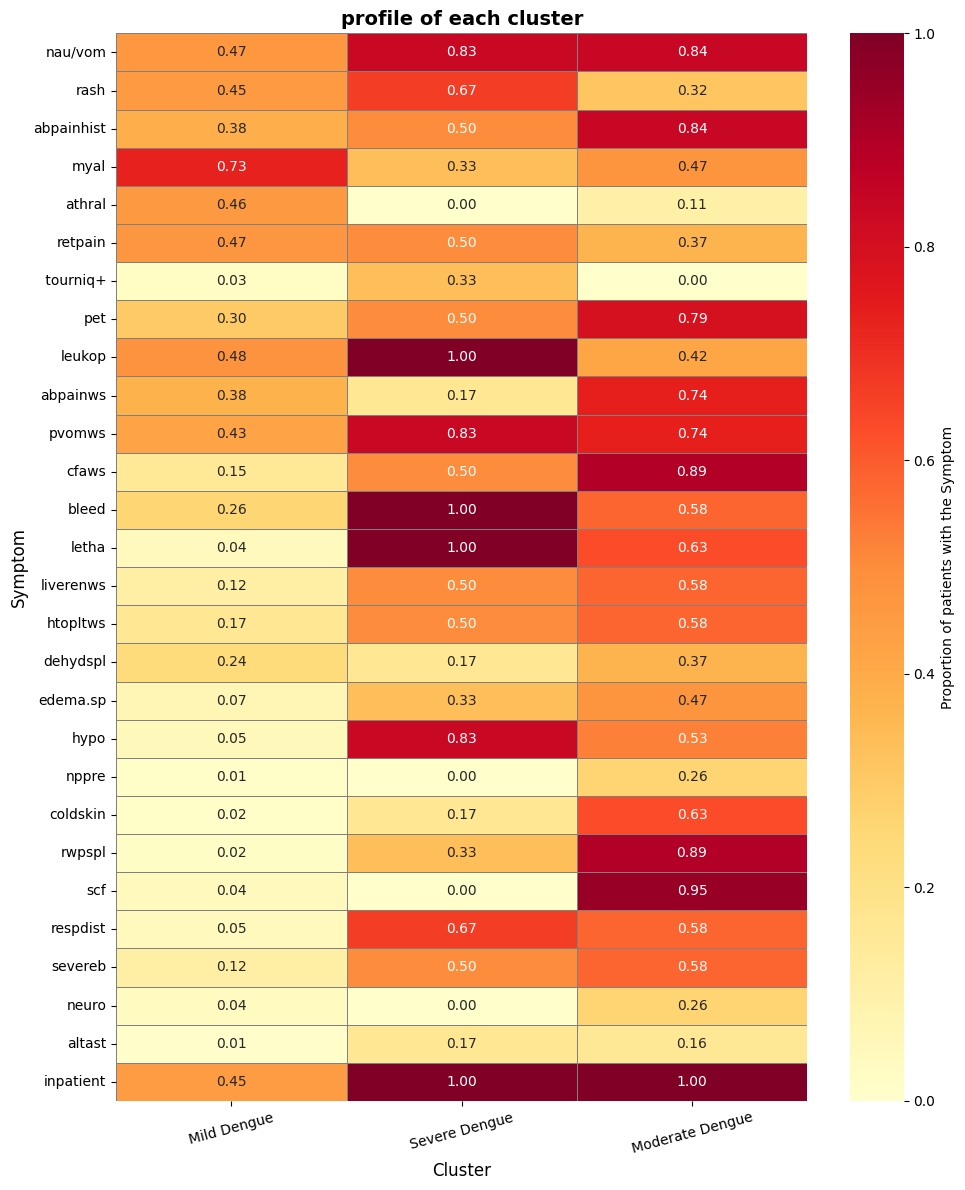

In [ ]:
# Clusters Profiles
cluster_profile = dengue_dataset.groupby('cluster').mean().T

plt.figure(figsize=(10, 12))
sns.heatmap(cluster_profile,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='gray',
            xticklabels=['Mild Dengue', 'Severe Dengue', 'Moderate Dengue'],
            cbar_kws={'label': 'Proportion of patients with the Symptom'})

plt.title('Profile of each cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Symptom', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
